=== HEAD ===
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

=== INFO ===
<class 'pandas.core.frame.Dat

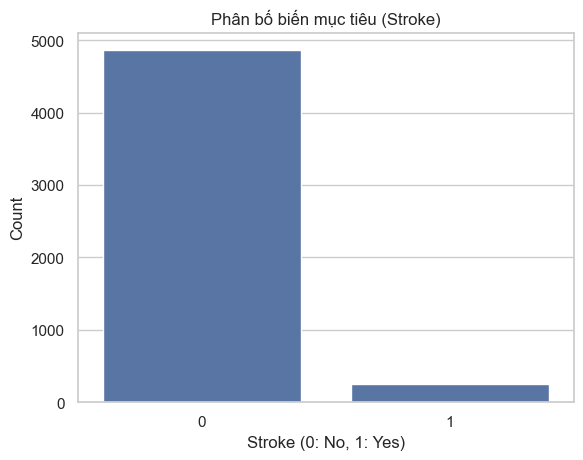

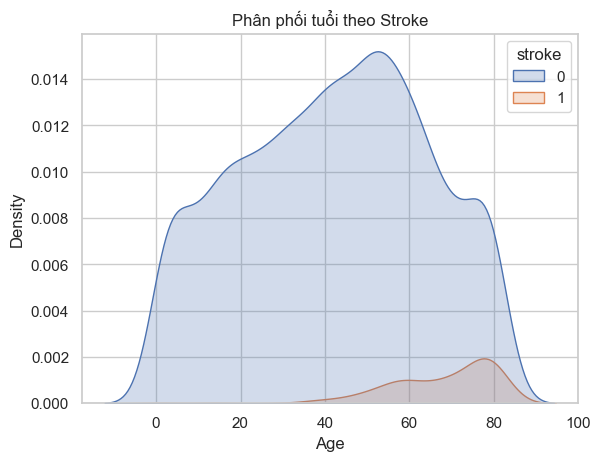

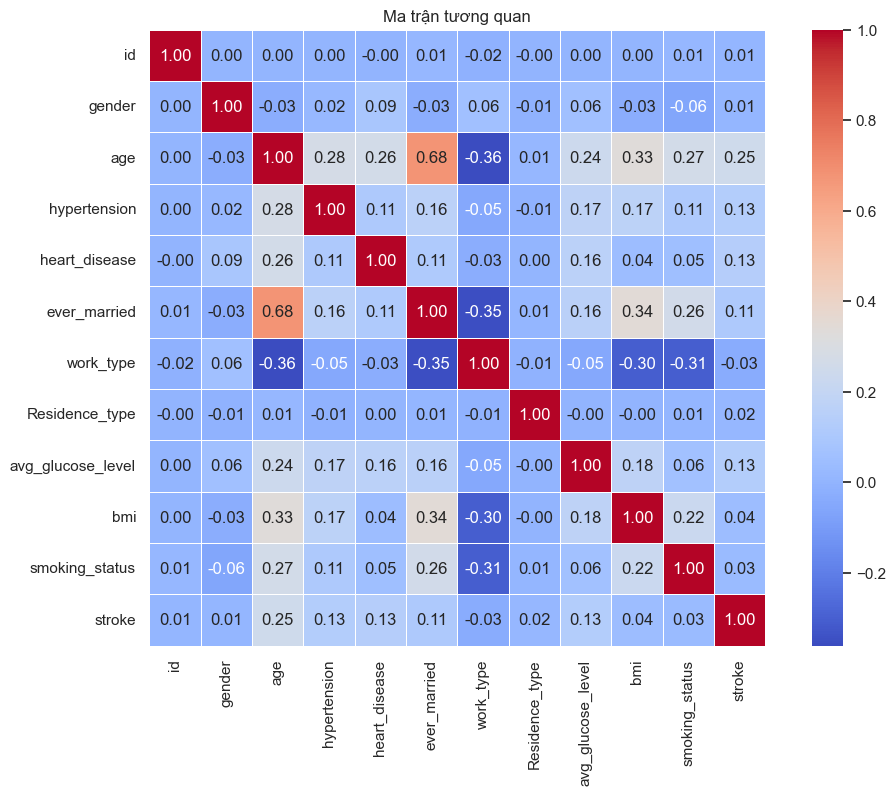

In [5]:
# =========================
# 1. IMPORT THƯ VIỆN
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# 2. NẠP DỮ LIỆU
# =========================
df = pd.read_csv("healthcare-dataset-stroke-data.csv")   # <-- đổi tên nếu cần

# xem dữ liệu
print("=== HEAD ===")
print(df.head())

# =========================
# 3. KIỂM TRA THÔNG TIN
# =========================
print("\n=== INFO ===")
print(df.info())

print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# =========================
# 4. COUNT PLOT (STROKE)
# =========================
plt.figure()
sns.countplot(x='stroke', data=df)
plt.title("Phân bố biến mục tiêu (Stroke)")
plt.xlabel("Stroke (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

# =========================
# 5. KDE PLOT (AGE)
# =========================
plt.figure()
sns.kdeplot(data=df, x='age', hue='stroke', fill=True)
plt.title("Phân phối tuổi theo Stroke")
plt.xlabel("Age")
plt.show()

# =========================
# 6. HEATMAP TƯƠNG QUAN
# =========================
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()
le = LabelEncoder()

# encode các cột dạng chữ
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# tính correlation
corr = df_corr.corr()

# vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",              # chỉ 2 chữ số thập phân
    cmap="coolwarm",
    linewidths=0.5,         # có đường ngăn
    square=True
)
plt.title("Ma trận tương quan")
plt.show()